In [1]:
from pathlib import Path

TEST_INPUT_DIR = Path("/Users/williamtsai/Desktop/nail_unusable_classifier/my_test")
TEST_CROP_DIR = Path("/Users/williamtsai/Desktop/nail_unusable_classifier/my_test_nail_crops")

MODEL_PATH = Path("best_segmented_polish_classifier_group_split_v2.pth")

print("TEST_INPUT_DIR exists:", TEST_INPUT_DIR.exists())
print("MODEL_PATH exists:", MODEL_PATH.exists())

TEST_INPUT_DIR exists: True
MODEL_PATH exists: True


In [2]:
import json
import shutil
import numpy as np
import cv2
from tqdm import tqdm
from pathlib import Path

if TEST_CROP_DIR.exists():
    shutil.rmtree(TEST_CROP_DIR)

TEST_CROP_DIR.mkdir(parents=True, exist_ok=True)

TARGET_LABELS = {"nail"}
EXCLUDE_LABELS = {"free_edge", "freeedge", "free-edge"}
MIN_PIXELS = 50

def normalize_label(label):
    return str(label).lower().strip().replace(" ", "_")

def is_valid_path(p: Path):
    s = str(p).lower()
    if "__macosx" in s:
        return False
    if p.name.startswith("._"):
        return False
    if "thumb" in s:
        return False
    return True

def find_image_for_json(json_path: Path, images_dir: Path):
    stem = json_path.stem
    for ext in [".png", ".jpg", ".jpeg", ".PNG", ".JPG", ".JPEG"]:
        cand = json_path.with_suffix(ext)
        if cand.exists() and is_valid_path(cand):
            return cand

    for ext in [".png", ".jpg", ".jpeg", ".PNG", ".JPG", ".JPEG"]:
        matches = [
            p for p in images_dir.rglob(f"{stem}{ext}")
            if p.is_file() and is_valid_path(p)
        ]
        if matches:
            return matches[0]

    return None

def polygon_to_mask(shape_points, h, w):
    pts = np.array(shape_points, dtype=np.float32)
    pts = np.round(pts).astype(np.int32)

    if len(pts) < 3:
        return np.zeros((h, w), dtype=np.uint8)

    pts[:, 0] = np.clip(pts[:, 0], 0, w - 1)
    pts[:, 1] = np.clip(pts[:, 1], 0, h - 1)

    mask = np.zeros((h, w), dtype=np.uint8)
    cv2.fillPoly(mask, [pts], 1)
    return mask

def tight_bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    return int(xs.min()), int(ys.min()), int(xs.max()), int(ys.max())

def apply_mask_and_crop(img_bgr, mask01):
    bbox = tight_bbox_from_mask(mask01)

    if bbox is None:
        return None

    x0, y0, x1, y1 = bbox
    m255 = (mask01.astype(np.uint8) * 255)

    masked = cv2.bitwise_and(img_bgr, img_bgr, mask=m255)
    crop = masked[y0:y1 + 1, x0:x1 + 1]

    return crop

json_files = sorted([
    p for p in TEST_INPUT_DIR.rglob("*.json")
    if p.is_file() and is_valid_path(p)
])

print("JSON files found:", len(json_files))

exported = 0
missing_images = []
skipped_no_nail = []
failed = []

for jp in tqdm(json_files):
    img_path = find_image_for_json(jp, TEST_INPUT_DIR)

    if img_path is None:
        missing_images.append(jp.name)
        continue

    try:
        data = json.loads(jp.read_text(encoding="utf-8"))

        img_bgr = cv2.imread(str(img_path), cv2.IMREAD_COLOR)
        if img_bgr is None:
            missing_images.append(jp.name)
            continue

        h, w = img_bgr.shape[:2]
        shapes = data.get("shapes", [])

        nail_shapes = [
            s for s in shapes
            if normalize_label(s.get("label", "")) in TARGET_LABELS
            and len(s.get("points", [])) >= 3
        ]

        exclude_shapes = [
            s for s in shapes
            if normalize_label(s.get("label", "")) in EXCLUDE_LABELS
            and len(s.get("points", [])) >= 3
        ]

        if not nail_shapes:
            skipped_no_nail.append(jp.name)
            continue

        exclude_mask = np.zeros((h, w), dtype=np.uint8)
        for s in exclude_shapes:
            exclude_mask |= polygon_to_mask(s["points"], h, w)

        for k, s in enumerate(nail_shapes, start=1):
            nail_mask = polygon_to_mask(s["points"], h, w)

            final_mask = (nail_mask & (exclude_mask == 0)).astype(np.uint8)

            if int(final_mask.sum()) < MIN_PIXELS:
                continue

            crop = apply_mask_and_crop(img_bgr, final_mask)

            if crop is None:
                continue

            if len(nail_shapes) == 1:
                out_name = f"{jp.stem}.png"
            else:
                out_name = f"{jp.stem}_nail_{k:02d}.png"

            cv2.imwrite(str(TEST_CROP_DIR / out_name), crop)
            exported += 1

    except Exception as e:
        failed.append((jp.name, str(e)))

print("\nDone.")
print("Exported nail crops:", exported)
print("Missing images:", len(missing_images))
print("Skipped no nail:", len(skipped_no_nail))
print("Failed:", len(failed))
print("Crop folder:", TEST_CROP_DIR)

if missing_images:
    print("First missing images:", missing_images[:10])

if skipped_no_nail:
    print("First skipped no nail:", skipped_no_nail[:10])

if failed:
    print("First failed:", failed[:10])

JSON files found: 7


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 7/7 [00:00<00:00, 26.39it/s]


Done.
Exported nail crops: 17
Missing images: 0
Skipped no nail: 0
Failed: 0
Crop folder: /Users/williamtsai/Desktop/nail_unusable_classifier/my_test_nail_crops


Test nail crops: 17


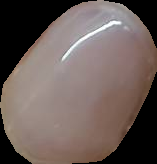

177719_nail_04.png


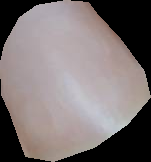

my_test_image_nail_04.png


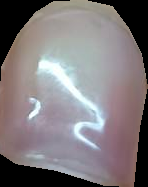

177732.png


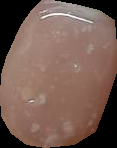

177719_nail_02.png


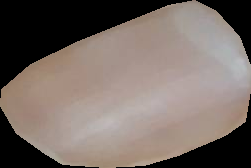

my_test_image_nail_01.png


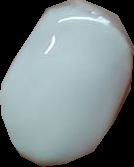

177719_nail_03.png


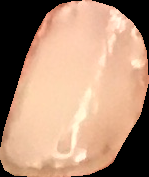

20210617184951_pid2625_VSPSbm_nail_01.png


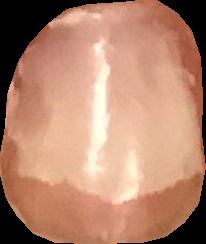

20210617184951_pid2625_VSPSbm_nail_03.png


In [3]:
from PIL import Image
from IPython.display import display
import random

test_crops = sorted(TEST_CROP_DIR.glob("*.png"))

print("Test nail crops:", len(test_crops))

for p in random.sample(test_crops, min(8, len(test_crops))):
    display(Image.open(p))
    print(p.name)

In [4]:
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import pandas as pd

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print("Device:", device)

class_names = ["no_polish", "polish"]

# same model architecture as training
model = models.resnet18(weights=None)

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 2)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

results = []

with torch.no_grad():
    for img_path in sorted(TEST_CROP_DIR.glob("*.png")):
        img = Image.open(img_path).convert("RGB")
        x = eval_transform(img).unsqueeze(0).to(device)

        outputs = model(x)
        probs = torch.softmax(outputs, dim=1)[0]

        pred_idx = int(torch.argmax(probs).item())
        pred_label = class_names[pred_idx]
        confidence = float(probs[pred_idx].item())

        results.append({
            "file": img_path.name,
            "prediction": pred_label,
            "confidence": confidence,
            "no_polish_prob": float(probs[0].item()),
            "polish_prob": float(probs[1].item())
        })

results_df = pd.DataFrame(results)
results_df

Device: mps


,file,prediction,confidence,no_polish_prob,polish_prob
0,177719_nail_01.png,polish,0.999519,0.000481,0.999519
1,177719_nail_02.png,polish,0.999400,0.000600,0.999400
2,177719_nail_03.png,polish,0.999617,0.000383,0.999617
3,177719_nail_04.png,polish,0.982497,0.017503,0.982497
4,177731.png,polish,0.967682,0.032318,0.967682
5,177732.png,polish,0.999170,0.000830,0.999170
6,177733.png,polish,0.999941,0.000059,0.999941
7,177734.png,polish,0.999408,0.000592,0.999408
8,20210617184951_pid2625_VSPSbm_nail_01.png,polish,0.999847,0.000153,0.999847
9,20210617184951_pid2625_VSPSbm_nail_02.png,polish,0.982769,0.017231,0.982769


In [5]:
import re

def get_original_group(filename):
    stem = Path(filename).stem
    stem = re.sub(r"_nail_\d+$", "", stem)
    stem = re.sub(r"_\d+$", "", stem)
    return stem

results_df["group"] = results_df["file"].apply(get_original_group)

summary = []

for group, g in results_df.groupby("group"):
    polish_mean = g["polish_prob"].mean()
    no_polish_mean = g["no_polish_prob"].mean()

    final_pred = "polish" if polish_mean >= 0.5 else "no_polish"

    summary.append({
        "group": group,
        "num_nail_crops": len(g),
        "final_prediction": final_pred,
        "avg_polish_prob": polish_mean,
        "avg_no_polish_prob": no_polish_mean
    })

summary_df = pd.DataFrame(summary)
summary_df

,group,num_nail_crops,final_prediction,avg_polish_prob,avg_no_polish_prob
0,177719,4,polish,0.995258,0.004742
1,177731,1,polish,0.967682,0.032318
2,177732,1,polish,0.999170,0.000830
3,177733,1,polish,0.999941,0.000059
4,177734,1,polish,0.999408,0.000592
5,20210617184951_pid2625_VSPSbm,4,polish,0.954222,0.045778
6,my_test_image,5,no_polish,0.039519,0.960481
